In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- paths ---
DATA_RAW = Path('../data/raw')

# --- plot style ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   1.2,
    'font.size':        12,
})
PALETTE = ['#1D9E75', '#3B8BD4', '#EF9F27', '#D85A30', '#7F77DD', '#888780']
print('Imports OK')

Imports OK


---
## Section 1 — Dataset overview & sanity checks

In [2]:
ratings  = pd.read_csv(DATA_RAW / 'ratings.csv',       dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32', 'timestamp': 'int64'})
movies   = pd.read_csv(DATA_RAW / 'movies.csv')
tags     = pd.read_csv(DATA_RAW / 'tags.csv')
genome_s = pd.read_csv(DATA_RAW / 'genome-scores.csv', dtype={'movieId': 'int32', 'tagId': 'int32', 'relevance': 'float32'})
genome_t = pd.read_csv(DATA_RAW / 'genome-tags.csv')
print('Done.')

Done.


In [3]:
files = {
    'ratings':       ratings,
    'movies':        movies,
    'tags':          tags,
    'genome_scores': genome_s,
    'genome_tags':   genome_t,
}
print(f"{'File':<18} {'Rows':>10} {'Cols':>6}")
print('-' * 36)
for name, df in files.items():
    print(f"{name:<18} {len(df):>10,} {df.shape[1]:>6}")

File                     Rows   Cols
------------------------------------
ratings            25,000,095      4
movies                 62,423      3
tags                1,093,360      4
genome_scores      15,584,448      3
genome_tags             1,128      2


In [4]:
# --- null counts ---
print('=== Null counts ===')
for name, df in files.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f'{name}: {nulls.to_dict()}')
    else:
        print(f'{name}: no nulls')

=== Null counts ===
ratings: no nulls
movies: no nulls
tags: {'tag': 16}
genome_scores: no nulls
genome_tags: no nulls


In [5]:
# --- duplicate check ---
print('=== Duplicate rows ===')
for name, df in files.items():
    dupes = df.duplicated().sum()
    print(f'{name}: {dupes:,} duplicate rows')

=== Duplicate rows ===
ratings: 0 duplicate rows
movies: 0 duplicate rows
tags: 0 duplicate rows
genome_scores: 0 duplicate rows
genome_tags: 0 duplicate rows


In [6]:
# --- timestamp range ---
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
print(f"Timestamp range: {ratings['datetime'].min().date()}  →  {ratings['datetime'].max().date()}")
print(f"Span: {(ratings['datetime'].max() - ratings['datetime'].min()).days // 365} years")

Timestamp range: 1995-01-09  →  2019-11-21
Span: 24 years


Movies in ratings:           59,047
Movies in movies.csv:        62,423
Rated movies NOT in movies:       0
Rated movies WITH genome:    13,816
Rated movies WITHOUT genome: 45,231


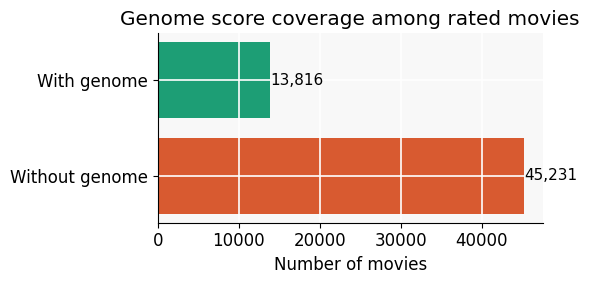

In [7]:
# --- movieId coverage ---
rating_movie_ids = set(ratings['movieId'].unique())
movie_ids        = set(movies['movieId'].unique())
genome_movie_ids = set(genome_s['movieId'].unique())

print(f"Movies in ratings:          {len(rating_movie_ids):>7,}")
print(f"Movies in movies.csv:       {len(movie_ids):>7,}")
print(f"Rated movies NOT in movies: {len(rating_movie_ids - movie_ids):>7,}")
print(f"Rated movies WITH genome:   {len(rating_movie_ids & genome_movie_ids):>7,}")
print(f"Rated movies WITHOUT genome:{len(rating_movie_ids - genome_movie_ids):>7,}")

# bar chart: genome coverage
with_genome    = len(rating_movie_ids & genome_movie_ids)
without_genome = len(rating_movie_ids - genome_movie_ids)

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(['Without genome', 'With genome'], [without_genome, with_genome],
        color=[PALETTE[3], PALETTE[0]])
ax.set_xlabel('Number of movies')
ax.set_title('Genome score coverage among rated movies')
for i, v in enumerate([without_genome, with_genome]):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

### Decision 1
> *Write your conclusion here after running the cells. Example:*
> Data is clean — no nulls in ratings. X% of rated movies have genome scores, so genome features will be usable for the majority of items.

---
## Section 2 — Rating distribution & relevance threshold
**Question:** What counts as a positive interaction?

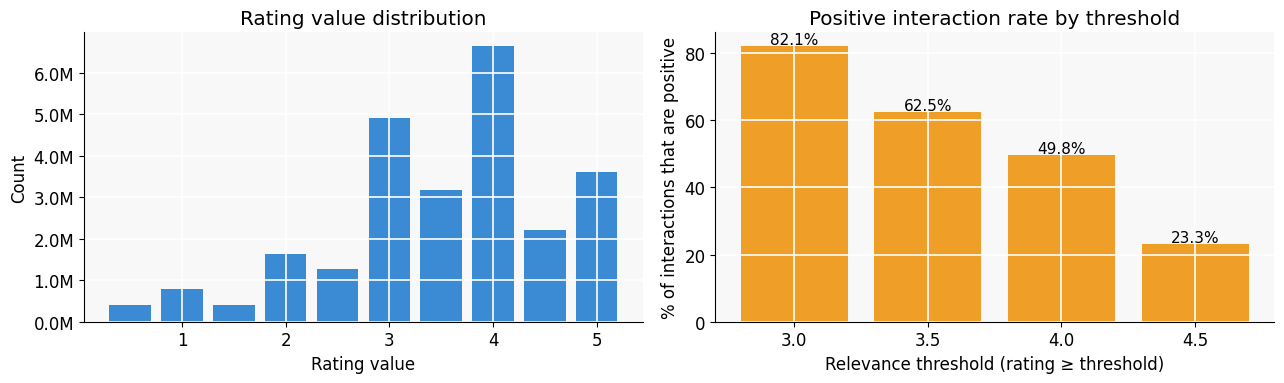

In [8]:
# --- overall rating distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: count per rating value
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, width=0.4, color=PALETTE[1])
axes[0].set_xlabel('Rating value')
axes[0].set_ylabel('Count')
axes[0].set_title('Rating value distribution')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# right: % positive at different thresholds
thresholds = [3.0, 3.5, 4.0, 4.5]
pct_positive = [(ratings['rating'] >= t).mean() * 100 for t in thresholds]
bars = axes[1].bar([str(t) for t in thresholds], pct_positive, color=PALETTE[2])
axes[1].set_xlabel('Relevance threshold (rating ≥ threshold)')
axes[1].set_ylabel('% of interactions that are positive')
axes[1].set_title('Positive interaction rate by threshold')
for bar, pct in zip(bars, pct_positive):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

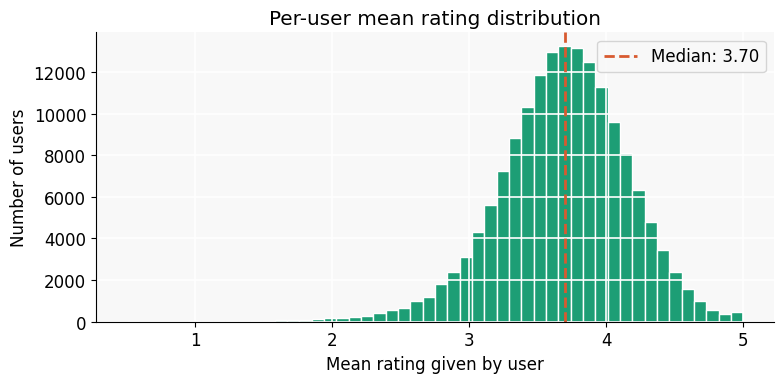

Mean of user means:   3.679
Median of user means: 3.700
Std of user means:    0.477


In [9]:
# --- per-user mean rating distribution ---
user_mean_rating = ratings.groupby('userId')['rating'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(user_mean_rating, bins=50, color=PALETTE[0], edgecolor='white')
ax.axvline(user_mean_rating.median(), color=PALETTE[3], linewidth=2,
           linestyle='--', label=f'Median: {user_mean_rating.median():.2f}')
ax.set_xlabel('Mean rating given by user')
ax.set_ylabel('Number of users')
ax.set_title('Per-user mean rating distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean of user means:   {user_mean_rating.mean():.3f}")
print(f"Median of user means: {user_mean_rating.median():.3f}")
print(f"Std of user means:    {user_mean_rating.std():.3f}")

In [10]:
# --- mark positive interactions using threshold = 4.0 (adjust if needed) ---
RELEVANCE_THRESHOLD = 4.0
ratings['is_positive'] = (ratings['rating'] >= RELEVANCE_THRESHOLD).astype('int8')

total       = len(ratings)
n_positive  = ratings['is_positive'].sum()
print(f"Threshold:          {RELEVANCE_THRESHOLD}")
print(f"Total interactions: {total:,}")
print(f"Positive:           {n_positive:,}  ({n_positive/total*100:.1f}%)")
print(f"Negative:           {total - n_positive:,}  ({(total-n_positive)/total*100:.1f}%)")

Threshold:          4.0
Total interactions: 25,000,095
Positive:           12,452,811  (49.8%)
Negative:           12,547,284  (50.2%)


### Decision 2
> *Write your conclusion here. Example:*
> Using threshold = 4.0 gives XX% positive interactions. This is acceptable / too sparse — adjusting to X.X.

---
## Section 3 — User activity distribution
**Question:** How many cold users exist and where should the cold-start threshold be?

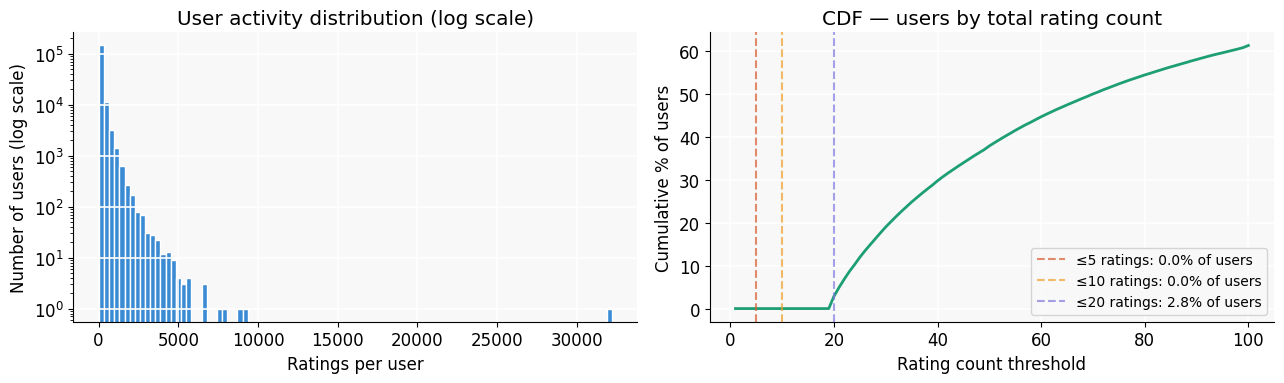

In [12]:
# --- ratings per user ---
user_rating_counts    = ratings.groupby('userId')['rating'].count()
user_positive_counts  = ratings[ratings['is_positive'] == 1].groupby('userId')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: log-scale histogram (all ratings)
axes[0].hist(user_rating_counts, bins=100, color=PALETTE[1], edgecolor='white', log=True)
axes[0].set_xlabel('Ratings per user')
axes[0].set_ylabel('Number of users (log scale)')
axes[0].set_title('User activity distribution (log scale)')

# right: cumulative % of users vs rating count threshold
thresholds_u = list(range(1, 101))
cdf_vals = [(user_rating_counts <= t).mean() * 100 for t in thresholds_u]
axes[1].plot(thresholds_u, cdf_vals, color=PALETTE[0], linewidth=2)
for cutoff, color in [(5, PALETTE[3]), (10, PALETTE[2]), (20, PALETTE[4])]:
    pct = (user_rating_counts <= cutoff).mean() * 100
    axes[1].axvline(cutoff, color=color, linestyle='--', alpha=0.7,
                    label=f'≤{cutoff} ratings: {pct:.1f}% of users')
axes[1].set_xlabel('Rating count threshold')
axes[1].set_ylabel('Cumulative % of users')
axes[1].set_title('CDF — users by total rating count')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

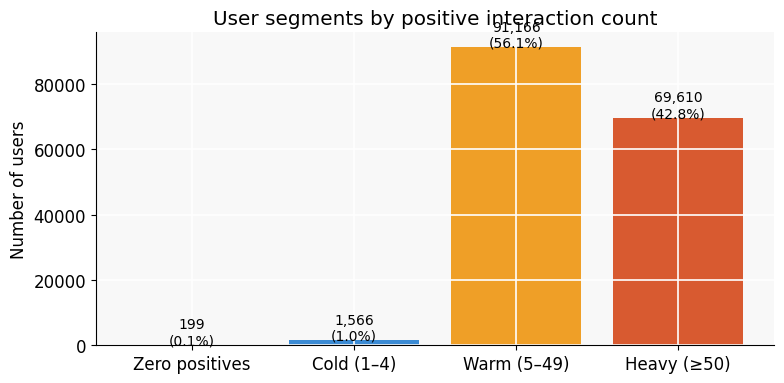

Total users: 162,541
Users with zero positives: 199


In [13]:
# --- cold / warm / heavy user bins (based on positive counts) ---
COLD_THRESHOLD = 5
HEAVY_THRESHOLD = 50

cold  = (user_positive_counts <  COLD_THRESHOLD).sum()
warm  = ((user_positive_counts >= COLD_THRESHOLD) & (user_positive_counts < HEAVY_THRESHOLD)).sum()
heavy = (user_positive_counts >= HEAVY_THRESHOLD).sum()
# users with zero positives won't appear in user_positive_counts
zero_positive = len(user_rating_counts) - len(user_positive_counts)

labels = ['Zero positives', f'Cold (1–{COLD_THRESHOLD-1})', f'Warm ({COLD_THRESHOLD}–{HEAVY_THRESHOLD-1})', f'Heavy (≥{HEAVY_THRESHOLD})']
counts = [zero_positive, cold, warm, heavy]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, counts, color=PALETTE[:4])
ax.set_ylabel('Number of users')
ax.set_title('User segments by positive interaction count')
for bar, count in zip(bars, counts):
    pct = count / len(user_rating_counts) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Total users: {len(user_rating_counts):,}")
print(f"Users with zero positives: {zero_positive:,}")

In [14]:
# --- summary stats ---
print('=== Ratings per user ===')
print(user_rating_counts.describe().apply(lambda x: f'{x:,.1f}'))
print(f"\nTop 10% of users account for: "
      f"{user_rating_counts[user_rating_counts >= user_rating_counts.quantile(0.9)].sum() / len(ratings) * 100:.1f}% of all ratings")

=== Ratings per user ===
count    162,541.0
mean         153.8
std          268.0
min           20.0
25%           36.0
50%           71.0
75%          162.0
max       32,202.0
Name: rating, dtype: object

Top 10% of users account for: 46.8% of all ratings


### Decision 3
> *Write your conclusion here. Example:*
> XX% of users have fewer than 5 positive interactions → these will be routed to the cold-start path. Cold-start threshold set at 5 positive interactions.

---
## Section 4 — Item popularity & long-tail
**Question:** How strong is popularity bias and where is the cold-item threshold?

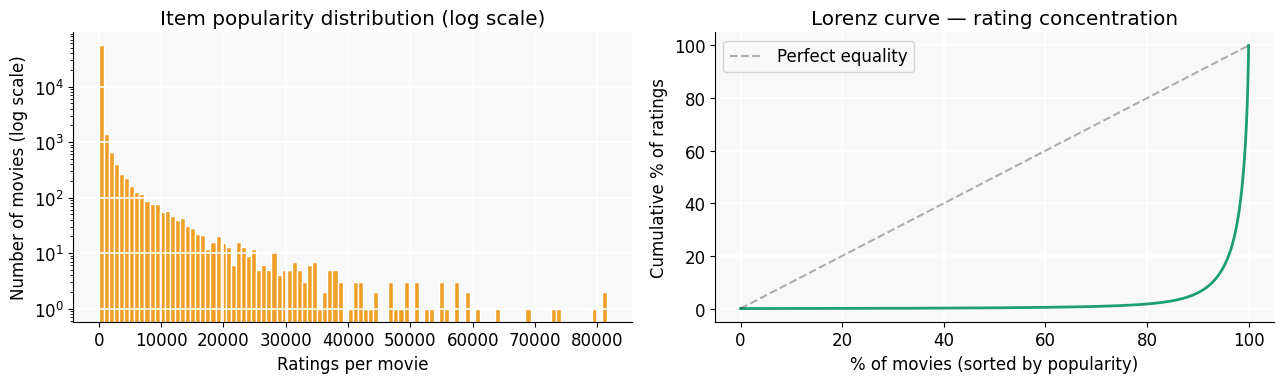

In [15]:
# --- ratings per movie ---
item_counts = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: log-scale histogram
axes[0].hist(item_counts, bins=100, color=PALETTE[2], edgecolor='white', log=True)
axes[0].set_xlabel('Ratings per movie')
axes[0].set_ylabel('Number of movies (log scale)')
axes[0].set_title('Item popularity distribution (log scale)')

# right: Lorenz-style — cumulative % of ratings vs % of items
sorted_counts = item_counts.sort_values()
cum_ratings = sorted_counts.cumsum() / sorted_counts.sum() * 100
pct_items   = np.linspace(0, 100, len(sorted_counts))
axes[1].plot(pct_items, cum_ratings.values, color=PALETTE[0], linewidth=2)
axes[1].plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Perfect equality')
axes[1].set_xlabel('% of movies (sorted by popularity)')
axes[1].set_ylabel('Cumulative % of ratings')
axes[1].set_title('Lorenz curve — rating concentration')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# --- concentration stats ---
total_movies = len(item_counts)
total_ratings = item_counts.sum()

for pct in [1, 5, 10, 20]:
    top_n   = max(1, int(total_movies * pct / 100))
    top_rat = item_counts.head(top_n).sum()
    print(f"Top {pct:>2}% of movies ({top_n:,}) → {top_rat/total_ratings*100:.1f}% of ratings")

print()
for threshold in [5, 10, 50, 100]:
    cold_items = (item_counts < threshold).sum()
    print(f"Movies with < {threshold:>3} ratings: {cold_items:,}  ({cold_items/total_movies*100:.1f}% of catalog)")

Top  1% of movies (590) → 47.6% of ratings
Top  5% of movies (2,952) → 84.5% of ratings
Top 10% of movies (5,904) → 94.0% of ratings
Top 20% of movies (11,809) → 98.3% of ratings

Movies with <   5 ratings: 26,327  (44.6% of catalog)
Movies with <  10 ratings: 34,717  (58.8% of catalog)
Movies with <  50 ratings: 45,871  (77.7% of catalog)
Movies with < 100 ratings: 48,721  (82.5% of catalog)


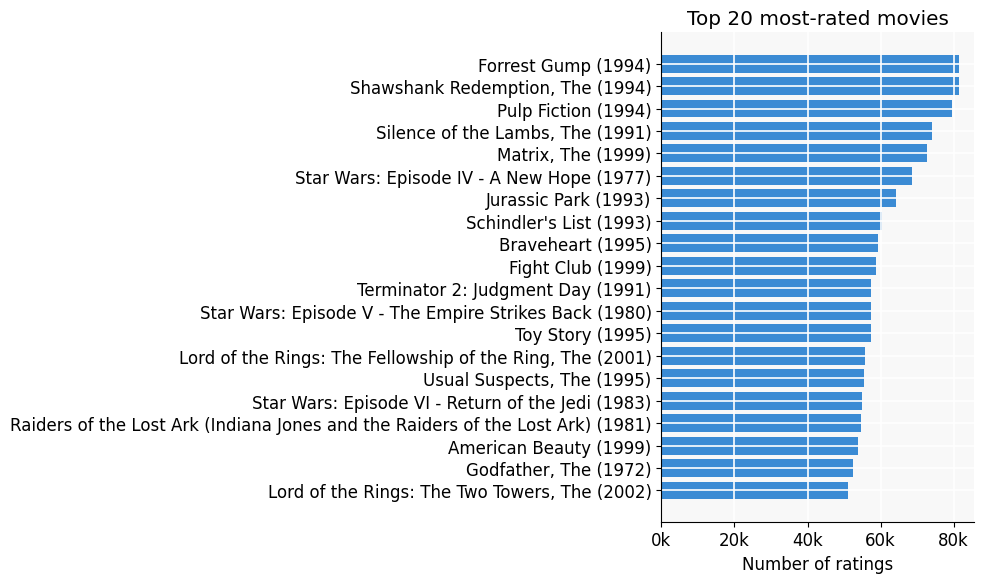

In [17]:
# --- top 20 most rated movies ---
top20 = (
    item_counts.head(20)
    .reset_index()
    .merge(movies[['movieId', 'title']], on='movieId')
    .sort_values('rating')
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20['title'], top20['rating'], color=PALETTE[1])
ax.set_xlabel('Number of ratings')
ax.set_title('Top 20 most-rated movies')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

### Decision 4
> *Write your conclusion here. Example:*
> Top 1% of movies account for XX% of ratings — strong popularity bias. Cold-item threshold set at 10 ratings. Diversity KPIs will need to be aggressive.

---
## Section 5 — Temporal patterns
**Question:** How should train/val/test be split?

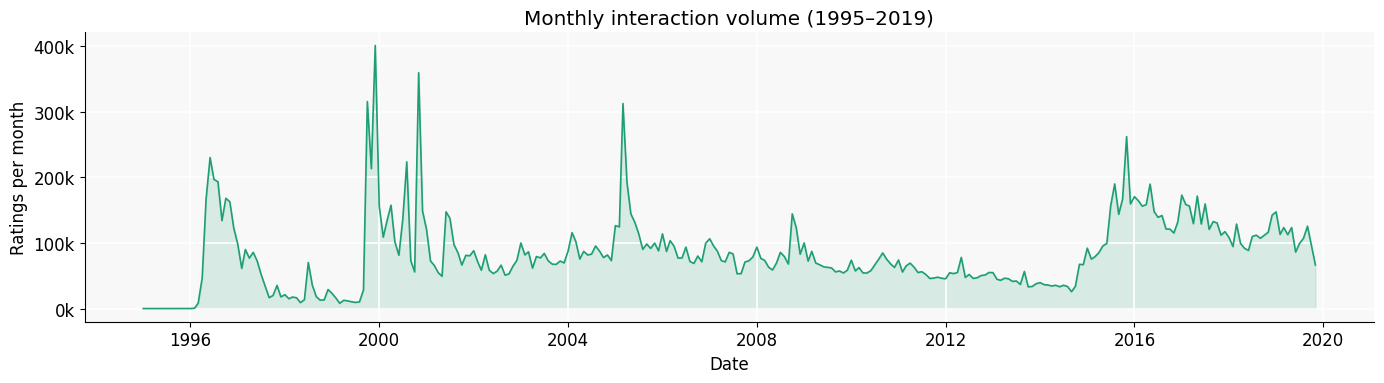

In [19]:
# --- monthly interaction volume ---
ratings['year_month'] = ratings['datetime'].dt.to_period('M')
monthly = ratings.groupby('year_month').size().reset_index(name='count')
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['year_month_dt'], monthly['count'], color=PALETTE[0], linewidth=1.2)
ax.fill_between(monthly['year_month_dt'], monthly['count'], alpha=0.15, color=PALETTE[0])
ax.set_xlabel('Date')
ax.set_ylabel('Ratings per month')
ax.set_title('Monthly interaction volume (1995–2019)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

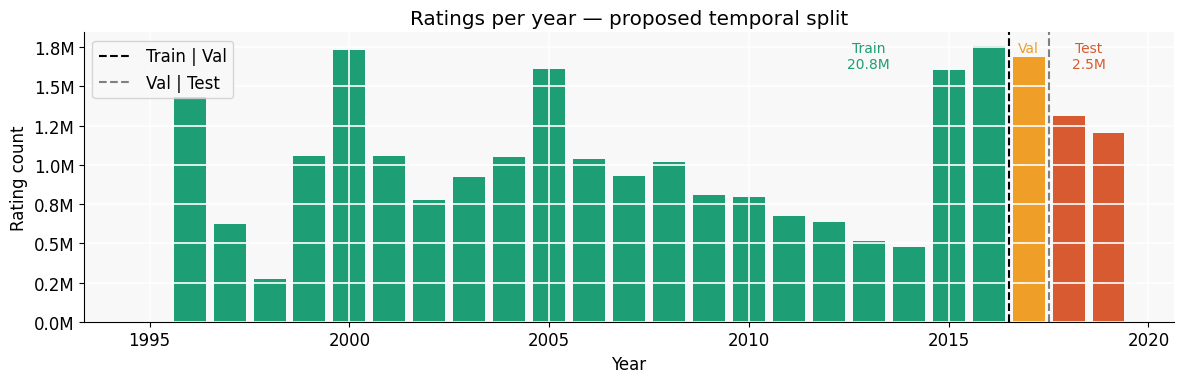

Train: 20,798,765 ratings  (83.2%)
Val:   1,689,935 ratings  (6.8%)
Test:  2,511,395 ratings  (10.0%)


In [20]:
# --- rating count by year with proposed split lines ---
ratings['year'] = ratings['datetime'].dt.year
yearly = ratings.groupby('year').size().reset_index(name='count')

# proposed split: train < 2017, val = 2017, test >= 2018 — adjust after seeing the chart
TRAIN_END = 2016
VAL_YEAR  = 2017
TEST_START = 2018

fig, ax = plt.subplots(figsize=(12, 4))
colors = [PALETTE[0] if y <= TRAIN_END else PALETTE[2] if y == VAL_YEAR else PALETTE[3]
          for y in yearly['year']]
ax.bar(yearly['year'], yearly['count'], color=colors)
ax.axvline(TRAIN_END + 0.5, color='black', linestyle='--', linewidth=1.5, label='Train | Val')
ax.axvline(VAL_YEAR  + 0.5, color='gray',  linestyle='--', linewidth=1.5, label='Val | Test')
ax.set_xlabel('Year')
ax.set_ylabel('Rating count')
ax.set_title('Ratings per year — proposed temporal split')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()

# annotate split sizes
train_n = (ratings['year'] <= TRAIN_END).sum()
val_n   = (ratings['year'] == VAL_YEAR).sum()
test_n  = (ratings['year'] >= TEST_START).sum()
ax.text(TRAIN_END - 3, yearly['count'].max() * 0.92, f'Train\n{train_n/1e6:.1f}M', ha='center', fontsize=10, color=PALETTE[0])
ax.text(VAL_YEAR,      yearly['count'].max() * 0.92, f'Val\n{val_n/1e6:.1f}M',   ha='center', fontsize=10, color=PALETTE[2])
ax.text(TEST_START + 0.5, yearly['count'].max() * 0.92, f'Test\n{test_n/1e6:.1f}M', ha='center', fontsize=10, color=PALETTE[3])

plt.tight_layout()
plt.show()

print(f"Train: {train_n:,} ratings  ({train_n/len(ratings)*100:.1f}%)")
print(f"Val:   {val_n:,} ratings  ({val_n/len(ratings)*100:.1f}%)")
print(f"Test:  {test_n:,} ratings  ({test_n/len(ratings)*100:.1f}%)")

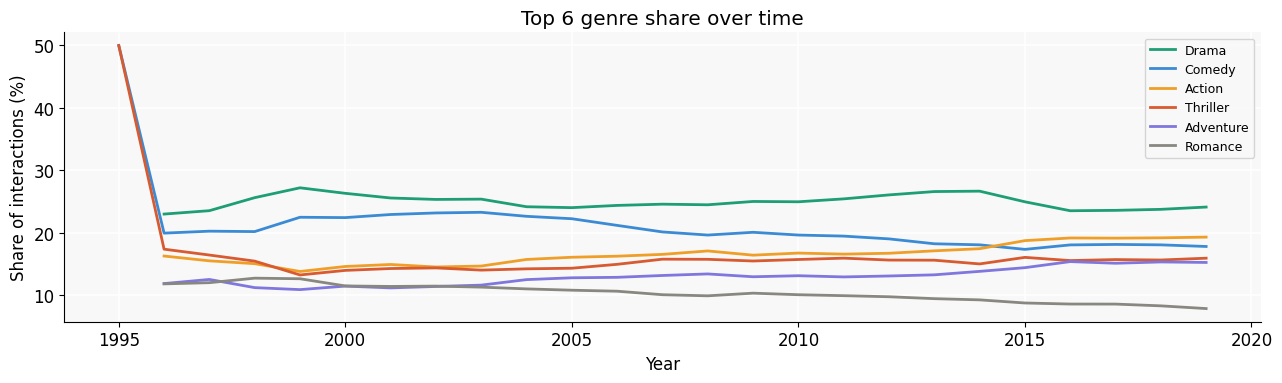

In [21]:
# --- genre share over time (top 6 genres) ---
movies_exploded = (
    movies.assign(genre=movies['genres'].str.split('|'))
    .explode('genre')
    [lambda df: df['genre'] != '(no genres listed)']
)

ratings_with_genre = ratings.merge(movies_exploded[['movieId', 'genre']], on='movieId')
top_genres = ratings_with_genre['genre'].value_counts().head(6).index.tolist()

genre_year = (
    ratings_with_genre[ratings_with_genre['genre'].isin(top_genres)]
    .groupby(['year', 'genre'])
    .size()
    .reset_index(name='count')
)
genre_total = genre_year.groupby('year')['count'].transform('sum')
genre_year['share'] = genre_year['count'] / genre_total * 100

fig, ax = plt.subplots(figsize=(13, 4))
for i, genre in enumerate(top_genres):
    g = genre_year[genre_year['genre'] == genre]
    ax.plot(g['year'], g['share'], label=genre, color=PALETTE[i % len(PALETTE)], linewidth=2)
ax.set_xlabel('Year')
ax.set_ylabel('Share of interactions (%)')
ax.set_title('Top 6 genre share over time')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

### Decision 5
> *Write your conclusion here. Example:*
> Train: pre-2017 (XX% of data). Val: 2017. Test: 2018+. Genre shares are stable over time — no major drift to worry about in features.

---
## Section 6 — Genre & tag-genome coverage
**Question:** How rich is the content signal for cold-start?

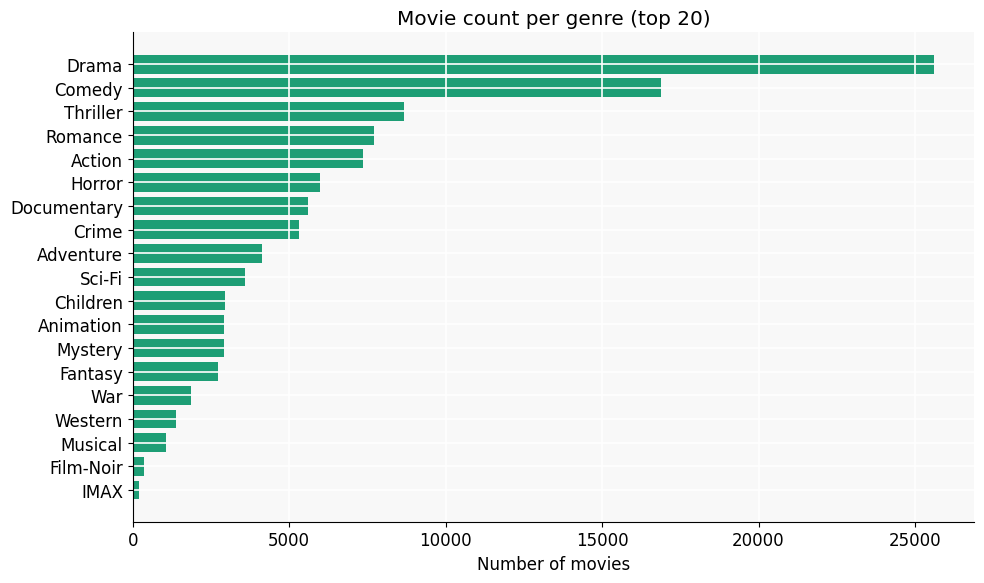

Movies with no genre listed: 5,062 (8.1%)


In [22]:
# --- genre distribution across catalog ---
genre_counts = (
    movies_exploded['genre']
    .value_counts()
    .reset_index()
)
genre_counts.columns = ['genre', 'count']
genre_counts = genre_counts[genre_counts['genre'] != '(no genres listed)'].head(20)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(genre_counts['genre'][::-1], genre_counts['count'][::-1], color=PALETTE[0])
ax.set_xlabel('Number of movies')
ax.set_title('Movie count per genre (top 20)')
plt.tight_layout()
plt.show()

no_genre = (movies['genres'] == '(no genres listed)').sum()
print(f"Movies with no genre listed: {no_genre:,} ({no_genre/len(movies)*100:.1f}%)")

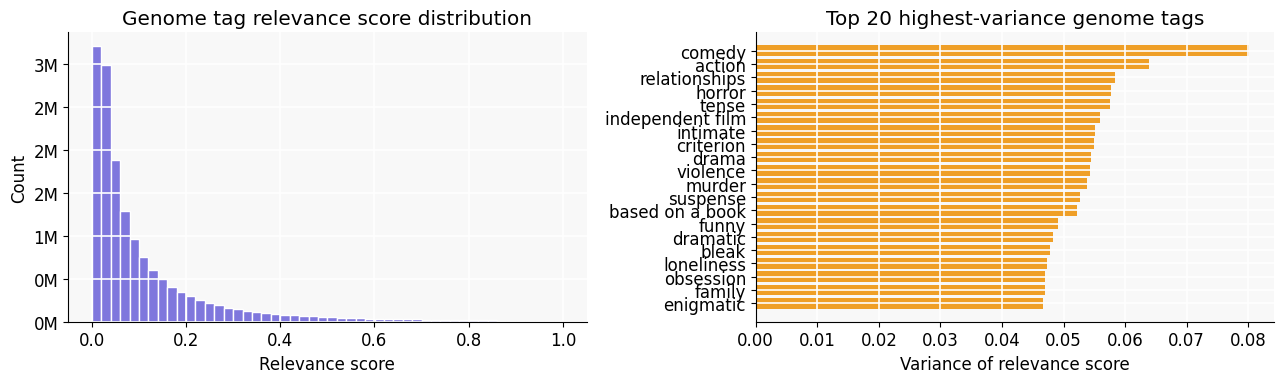

In [23]:
# --- genome tag relevance distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: histogram of relevance scores
axes[0].hist(genome_s['relevance'], bins=50, color=PALETTE[4], edgecolor='white')
axes[0].set_xlabel('Relevance score')
axes[0].set_ylabel('Count')
axes[0].set_title('Genome tag relevance score distribution')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# right: top 20 highest-variance genome tags (most discriminative)
tag_variance = (
    genome_s.groupby('tagId')['relevance']
    .var()
    .reset_index()
    .merge(genome_t, on='tagId')
    .sort_values('relevance', ascending=False)
    .head(20)
)

axes[1].barh(tag_variance['tag'][::-1], tag_variance['relevance'][::-1], color=PALETTE[2])
axes[1].set_xlabel('Variance of relevance score')
axes[1].set_title('Top 20 highest-variance genome tags')

plt.tight_layout()
plt.show()

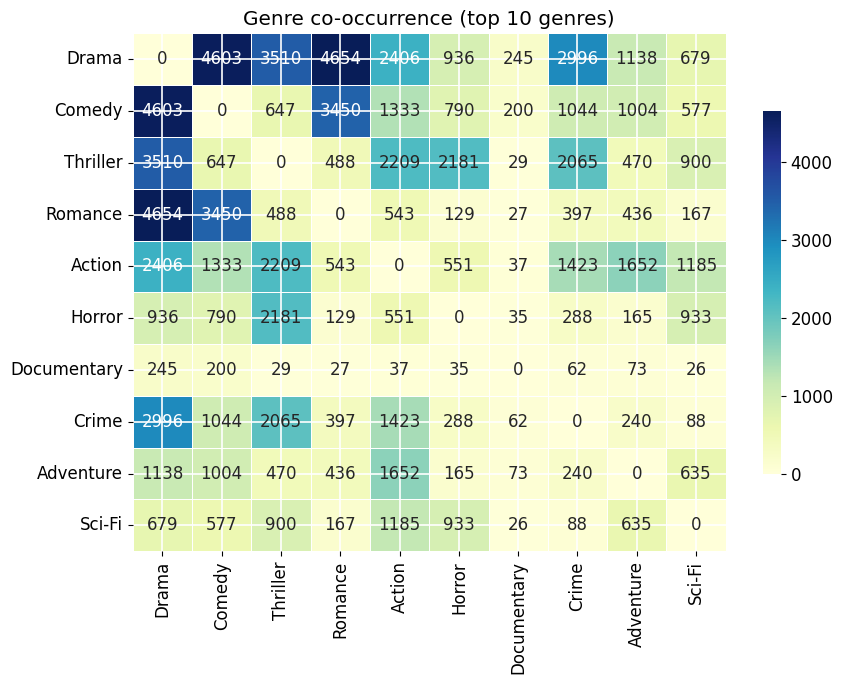

In [24]:
# --- genre co-occurrence heatmap ---
from itertools import combinations

top_genres_heatmap = (
    movies_exploded['genre']
    .value_counts()
    .head(10)
    .index.tolist()
)

cooccurrence = pd.DataFrame(0, index=top_genres_heatmap, columns=top_genres_heatmap)

for _, group in movies_exploded[movies_exploded['genre'].isin(top_genres_heatmap)].groupby('movieId')['genre']:
    genres_in_movie = list(set(group) & set(top_genres_heatmap))
    for g1, g2 in combinations(genres_in_movie, 2):
        cooccurrence.loc[g1, g2] += 1
        cooccurrence.loc[g2, g1] += 1

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cooccurrence, annot=True, fmt='d', cmap='YlGnBu',
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7}
)
ax.set_title('Genre co-occurrence (top 10 genres)')
plt.tight_layout()
plt.show()

In [25]:
# --- tag density per movie ---
tags_per_movie = tags.groupby('movieId')['tag'].count()
print(f"Movies with at least 1 user tag: {len(tags_per_movie):,} ({len(tags_per_movie)/len(movies)*100:.1f}% of catalog)")
print(f"Median tags per movie: {tags_per_movie.median():.0f}")
print(f"Mean tags per movie:   {tags_per_movie.mean():.1f}")

Movies with at least 1 user tag: 45,251 (72.5% of catalog)
Median tags per movie: 5
Mean tags per movie:   24.2
